# Bank Fraud Detection
End-to-end ML pipeline: EDA -> Feature Engineering -> Model Training -> Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
OUTPUT_DIR = os.path.dirname(os.path.abspath("__file__"))

## 1. Load Data

In [2]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "bank_fraud.csv"))
print(f"Shape: {df.shape}")
print(df.dtypes)
df.head(3)

Shape: (1000000, 26)
transaction_id                  str
customer_id                     str
transaction_date                str
transaction_time                str
hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                         str
city                            str
merchant_category               str
payment_method                  str
device_type                     str
customer_age                  int64
credit_score                  int64
account_age_years           float64
account_balance             float64
transaction_amount          float64
num_prev_transactions         int64
transaction_freq_monthly      int64
distance_from_home_km       float64
time_since_last_txn_hrs     float64
is_international              int64
failed_attempts               int64
pin_changed_recently          int64
is_fraud                      int64
fraud_type                      str
dtype: object


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN


## 2. Exploratory Data Analysis

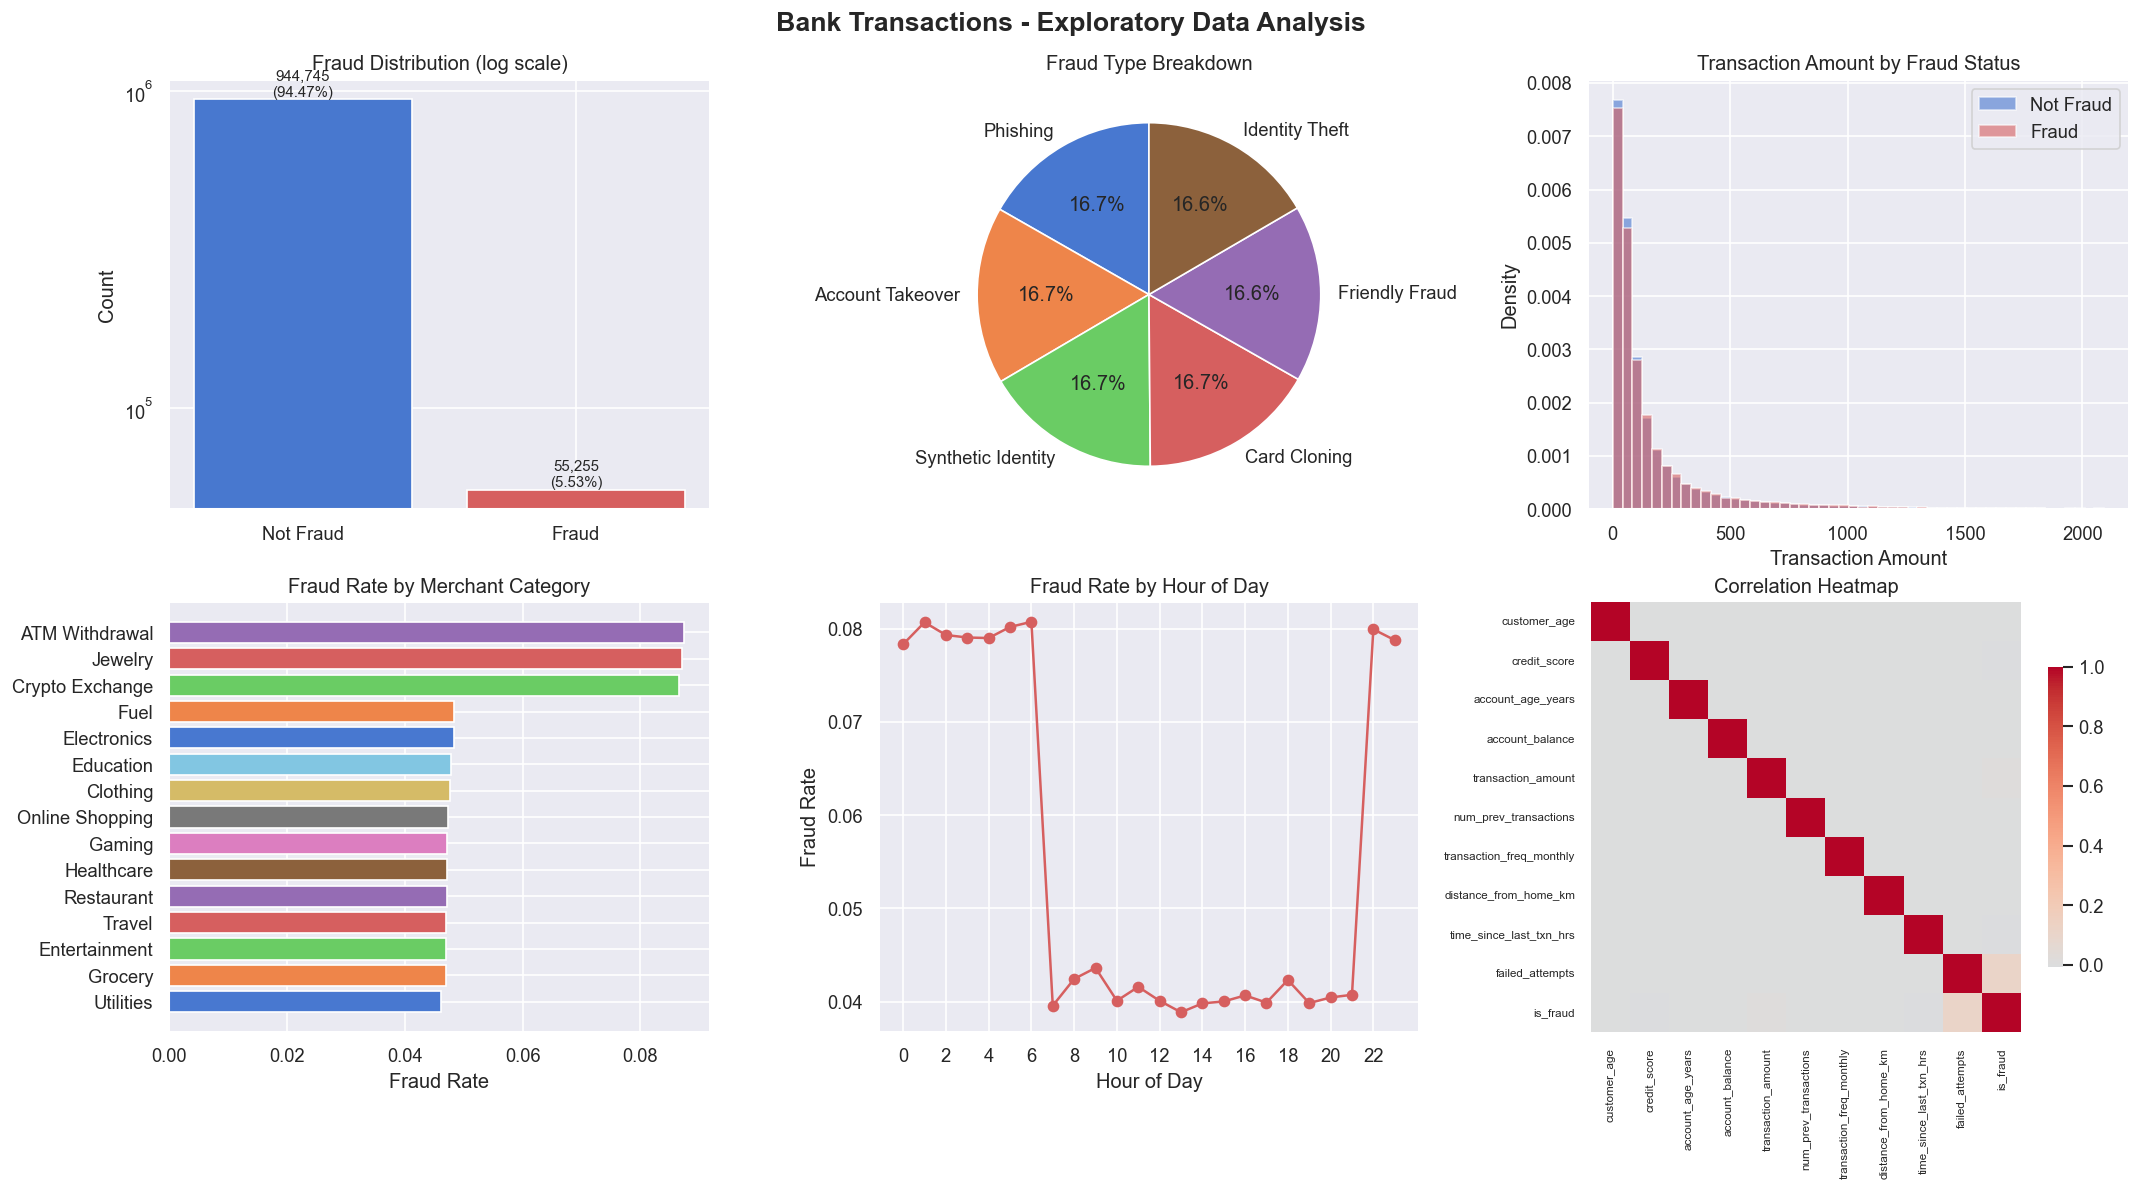

Saved eda_plots.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Bank Transactions - Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Fraud distribution
ax = axes[0, 0]
vc = df["is_fraud"].value_counts().sort_index()
colors = ["#4878CF", "#D65F5F"]
ax.bar(["Not Fraud", "Fraud"], vc.values, color=colors)
ax.set_yscale("log")
ax.set_title("Fraud Distribution (log scale)")
ax.set_ylabel("Count")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}\n({v/len(df)*100:.2f}%)", ha="center", va="bottom", fontsize=9)

# Fraud type breakdown
ax = axes[0, 1]
ft = df.loc[df["is_fraud"] == 1, "fraud_type"].value_counts()
ax.pie(ft.values, labels=ft.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("muted", len(ft)))
ax.set_title("Fraud Type Breakdown")

# Transaction amount by fraud status
ax = axes[0, 2]
cap = df["transaction_amount"].quantile(0.99)
ax.hist(df.loc[df["is_fraud"] == 0, "transaction_amount"], bins=50, range=(0, cap),
        alpha=0.6, label="Not Fraud", color="#4878CF", density=True)
ax.hist(df.loc[df["is_fraud"] == 1, "transaction_amount"], bins=50, range=(0, cap),
        alpha=0.6, label="Fraud", color="#D65F5F", density=True)
ax.set_title("Transaction Amount by Fraud Status")
ax.set_xlabel("Transaction Amount"); ax.set_ylabel("Density")
ax.legend()

# Fraud rate by merchant category
ax = axes[1, 0]
rate = df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)
ax.barh(rate.index[::-1], rate.values[::-1], color=sns.color_palette("muted", len(rate)))
ax.set_title("Fraud Rate by Merchant Category")
ax.set_xlabel("Fraud Rate")

# Fraud rate by hour of day
ax = axes[1, 1]
rate_hour = df.groupby("hour_of_day")["is_fraud"].mean()
ax.plot(rate_hour.index, rate_hour.values, marker="o", color="#D65F5F")
ax.set_title("Fraud Rate by Hour of Day")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Fraud Rate")
ax.set_xticks(range(0, 24, 2))

# Correlation heatmap
ax = axes[1, 2]
num_cols = ["customer_age", "credit_score", "account_age_years", "account_balance",
            "transaction_amount", "num_prev_transactions", "transaction_freq_monthly",
            "distance_from_home_km", "time_since_last_txn_hrs", "failed_attempts", "is_fraud"]
corr = df[num_cols].corr()
sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Heatmap")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_plots.png"), bbox_inches="tight")
plt.show()
print("Saved eda_plots.png")

## 3. Feature Engineering

In [4]:
data = df.copy()

cat_cols = ["country", "city", "merchant_category", "payment_method", "device_type"]
for col in cat_cols:
    data[col + "_enc"] = LabelEncoder().fit_transform(data[col])

FEATURES = [
    "hour_of_day", "is_weekend", "is_night_transaction",
    "customer_age", "credit_score", "account_age_years", "account_balance",
    "transaction_amount", "num_prev_transactions", "transaction_freq_monthly",
    "distance_from_home_km", "time_since_last_txn_hrs", "is_international",
    "failed_attempts", "pin_changed_recently",
    "country_enc", "city_enc", "merchant_category_enc", "payment_method_enc", "device_type_enc",
]
TARGET = "is_fraud"

X = data[FEATURES]
y = data[TARGET]

print(f"Feature matrix: {X.shape}")
print(f"Fraud rate: {y.mean() * 100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Feature matrix: (1000000, 20)
Fraud rate: 5.53%


Train: (800000, 20)  Test: (200000, 20)


## 4. Train Models

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=16, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100, class_weight="balanced", random_state=42
    ),
}

results = {}
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cv = cross_val_score(model, X, y, cv=3, scoring="roc_auc", n_jobs=-1).mean()

    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": auc, "cv_roc_auc": cv,
    }
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-score   : {f1:.4f}")
    print(f"  ROC-AUC    : {auc:.4f}")
    print(f"  CV ROC-AUC : {cv:.4f}")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print()

Training Logistic Regression ...


  Accuracy   : 0.6708
  Precision  : 0.0973
  Recall     : 0.5989
  F1-score   : 0.1674
  ROC-AUC    : 0.6963
  CV ROC-AUC : 0.7000
              precision    recall  f1-score   support

           0     0.9664    0.6750    0.7948    188949
           1     0.0973    0.5989    0.1674     11051

    accuracy                         0.6708    200000
   macro avg     0.5318    0.6369    0.4811    200000
weighted avg     0.9184    0.6708    0.7602    200000


Training Random Forest ...


  Accuracy   : 0.7322
  Precision  : 0.1079
  Recall     : 0.5294
  F1-score   : 0.1793
  ROC-AUC    : 0.7061
  CV ROC-AUC : 0.7079
              precision    recall  f1-score   support

           0     0.9643    0.7440    0.8400    188949
           1     0.1079    0.5294    0.1793     11051

    accuracy                         0.7322    200000
   macro avg     0.5361    0.6367    0.5096    200000
weighted avg     0.9170    0.7322    0.8035    200000


Training Hist Gradient Boosting ...


  Accuracy   : 0.6648
  Precision  : 0.1030
  Recall     : 0.6571
  F1-score   : 0.1781
  ROC-AUC    : 0.7246
  CV ROC-AUC : 0.7259
              precision    recall  f1-score   support

           0     0.9707    0.6653    0.7895    188949
           1     0.1030    0.6571    0.1781     11051

    accuracy                         0.6648    200000
   macro avg     0.5369    0.6612    0.4838    200000
weighted avg     0.9228    0.6648    0.7557    200000




## 5. Results Visualisations

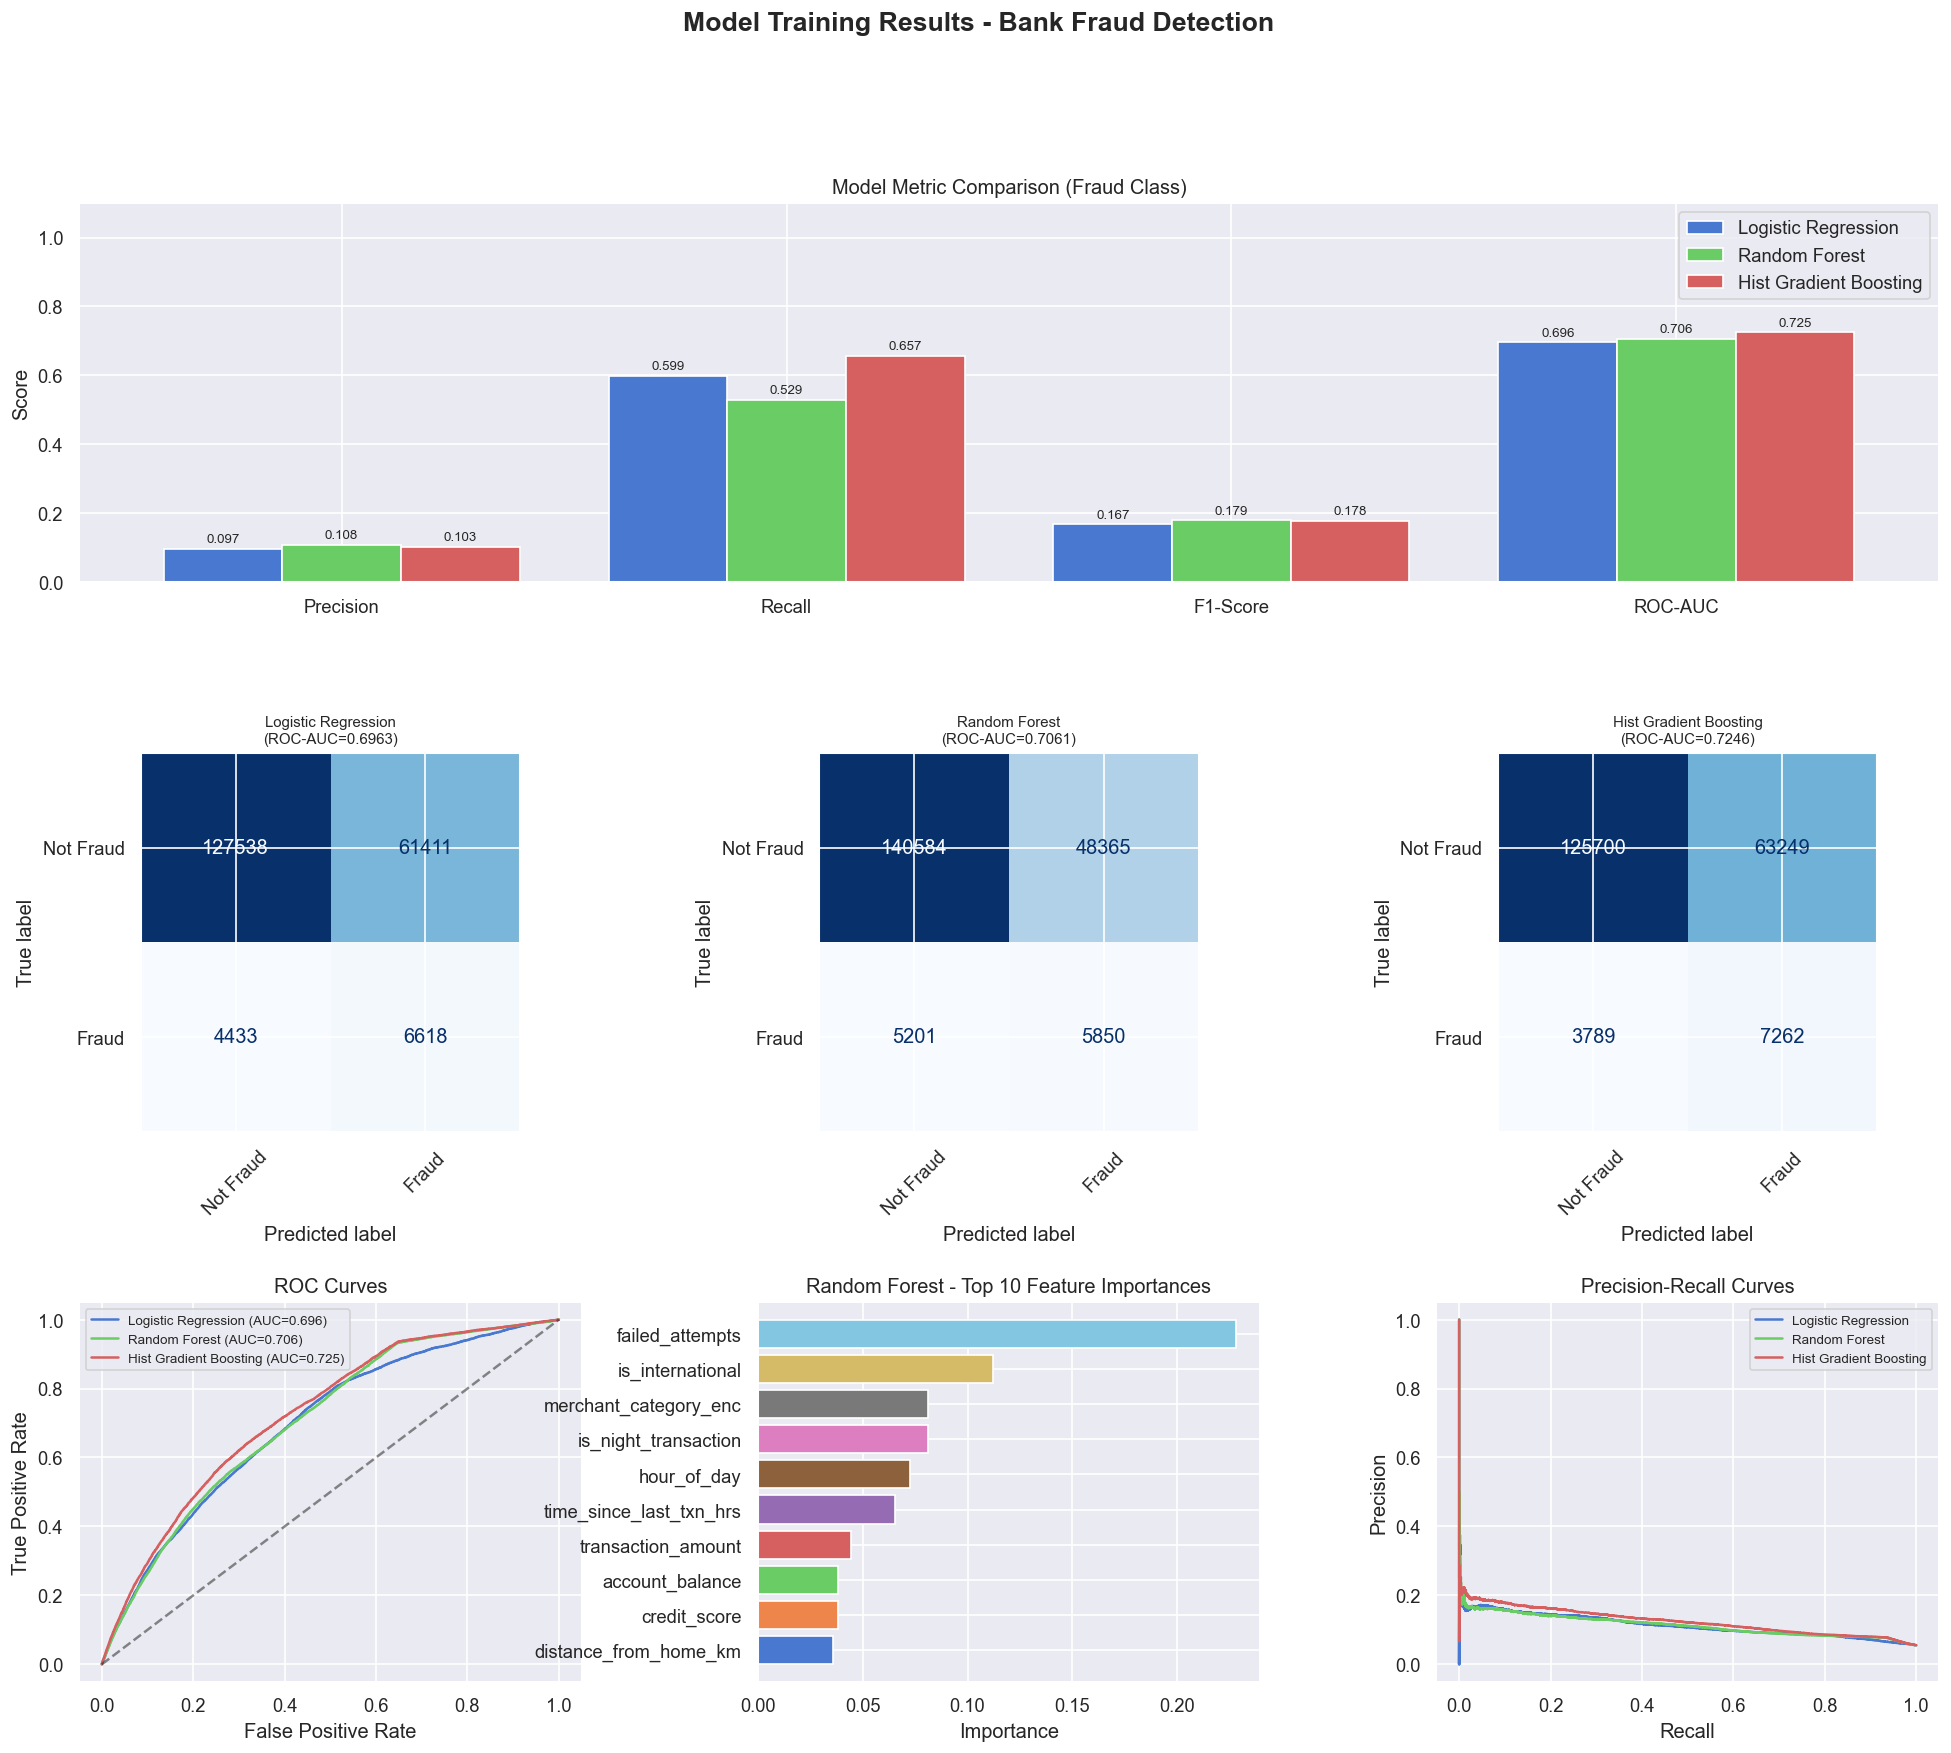

Saved model_results.png


In [6]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Model Training Results - Bank Fraud Detection", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
colors = ["#4878CF", "#6ACC65", "#D65F5F"]
names = list(results.keys())

# Metric comparison bar chart
ax_cmp = fig.add_subplot(gs[0, :])
metrics = ["precision", "recall", "f1", "roc_auc"]
metric_labels = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.8 / len(names)
for i, name in enumerate(names):
    vals = [results[name][m] for m in metrics]
    bars = ax_cmp.bar(x + (i - 1) * width, vals, width, label=name, color=colors[i])
    for bar, v in zip(bars, vals):
        ax_cmp.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax_cmp.set_xticks(x); ax_cmp.set_xticklabels(metric_labels, fontsize=11)
ax_cmp.set_ylim(0, 1.1)
ax_cmp.set_ylabel("Score")
ax_cmp.set_title("Model Metric Comparison (Fraud Class)")
ax_cmp.legend()

# Confusion matrices
for i, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Fraud", "Fraud"])
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(f"{name}\n(ROC-AUC={res['roc_auc']:.4f})", fontsize=9)
    ax_cm.tick_params(axis="x", rotation=45)

# ROC curves
ax_roc = fig.add_subplot(gs[2, 0])
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=colors[i])
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax_roc.set_title("ROC Curves")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(fontsize=8)

# Feature importance (Random Forest)
ax_fi = fig.add_subplot(gs[2, 1])
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values().tail(10)
ax_fi.barh(importances.index, importances.values, color=sns.color_palette("muted", len(importances)))
ax_fi.set_title("Random Forest - Top 10 Feature Importances")
ax_fi.set_xlabel("Importance")

# Precision-Recall curves
ax_pr = fig.add_subplot(gs[2, 2])
for i, (name, res) in enumerate(results.items()):
    p, r, _ = precision_recall_curve(y_test, res["y_proba"])
    ax_pr.plot(r, p, label=name, color=colors[i])
ax_pr.set_title("Precision-Recall Curves")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.legend(fontsize=8)

plt.savefig(os.path.join(OUTPUT_DIR, "model_results.png"), bbox_inches="tight")
plt.show()
print("Saved model_results.png")

## 6. Best Model Summary

In [7]:
best_name = max(results, key=lambda n: results[n]["roc_auc"])
best = results[best_name]
print(f"{'='*50}")
print(f"Best model : {best_name}")
print(f"ROC-AUC    : {best['roc_auc']:.4f}")
print(f"CV ROC-AUC : {best['cv_roc_auc']:.4f}")
print(f"Precision  : {best['precision']:.4f}")
print(f"Recall     : {best['recall']:.4f}")
print(f"F1-score   : {best['f1']:.4f}")
print(f"{'='*50}")
print("\nPlots saved to:", OUTPUT_DIR)

Best model : Hist Gradient Boosting
ROC-AUC    : 0.7246
CV ROC-AUC : 0.7259
Precision  : 0.1030
Recall     : 0.6571
F1-score   : 0.1781

Plots saved to: D:\ANIMESH\ML projects\EDA-Model-Comparison-main\Bank fraud detection
